1. Project Objectives
The primary goal is to understand the drivers of real estate prices in California and build a predictive model to estimate house values. This helps stakeholders make data-driven decisions rather than relying on intuition.

Predictive Goal: Build a regression model to predict the median_house_value based on location and neighborhood demographics.

Analytical Goal: Identify which factors (e.g., proximity to the ocean vs. household income) have the strongest impact on property appreciation.

2. Stakeholders
Real Estate Investors: To identify "undervalued" areas where current prices are lower than predicted by the model.

Urban Planners: To understand how population density and housing age affect regional wealth.

Mortgage Lenders: To assess the risk and collateral value of properties in specific geographic clusters.

In [ ]:
#write all the pip install stuff here

In [15]:
# Standard libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Geospatial
import geopandas as gpd
import geoplot as gplt
import geoplot.crs as gcrs

# Scikit-learn core
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

# Scikit-learn preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer

# Scikit-learn models / utilities
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

#import data
df=pd.read_csv('housing.csv')

Sanitary Check

In [ ]:
print("Shape of the Dataset:", df.shape, "\n")
print("First Few Rows of the Dataset:")
print(df.head(10), "\n\n")
print("Dataset Information:")
print(df.info(), "\n\n")
print("Number of Missing Values in Each Column:")
print(df.isna().sum(), "\n\n")
print("Number of Duplicated Rows:\n", df.duplicated().sum(), "\n\n")
print("Description of the Numerical Dataset:\n", df.describe(), "\n\n")
print("Description of Categorical Columns:\n", df.describe(include='object'), "\n\n")
print("Number of Unique Values in Each Column:\n", df.nunique(), "\n\n")

Preliminary tweaks

In [20]:
#change the column name to accurately reflect the data it contains
df = df.rename(columns={
    "total_rooms": "total_rooms_block",
    "total_bedrooms": "total_bedrooms_block",
    "population": "population_block",
    "households": "num_households",
    "median_income": "median_income_10k",
    "housing_median_age": "median_house_age"
})

EDA

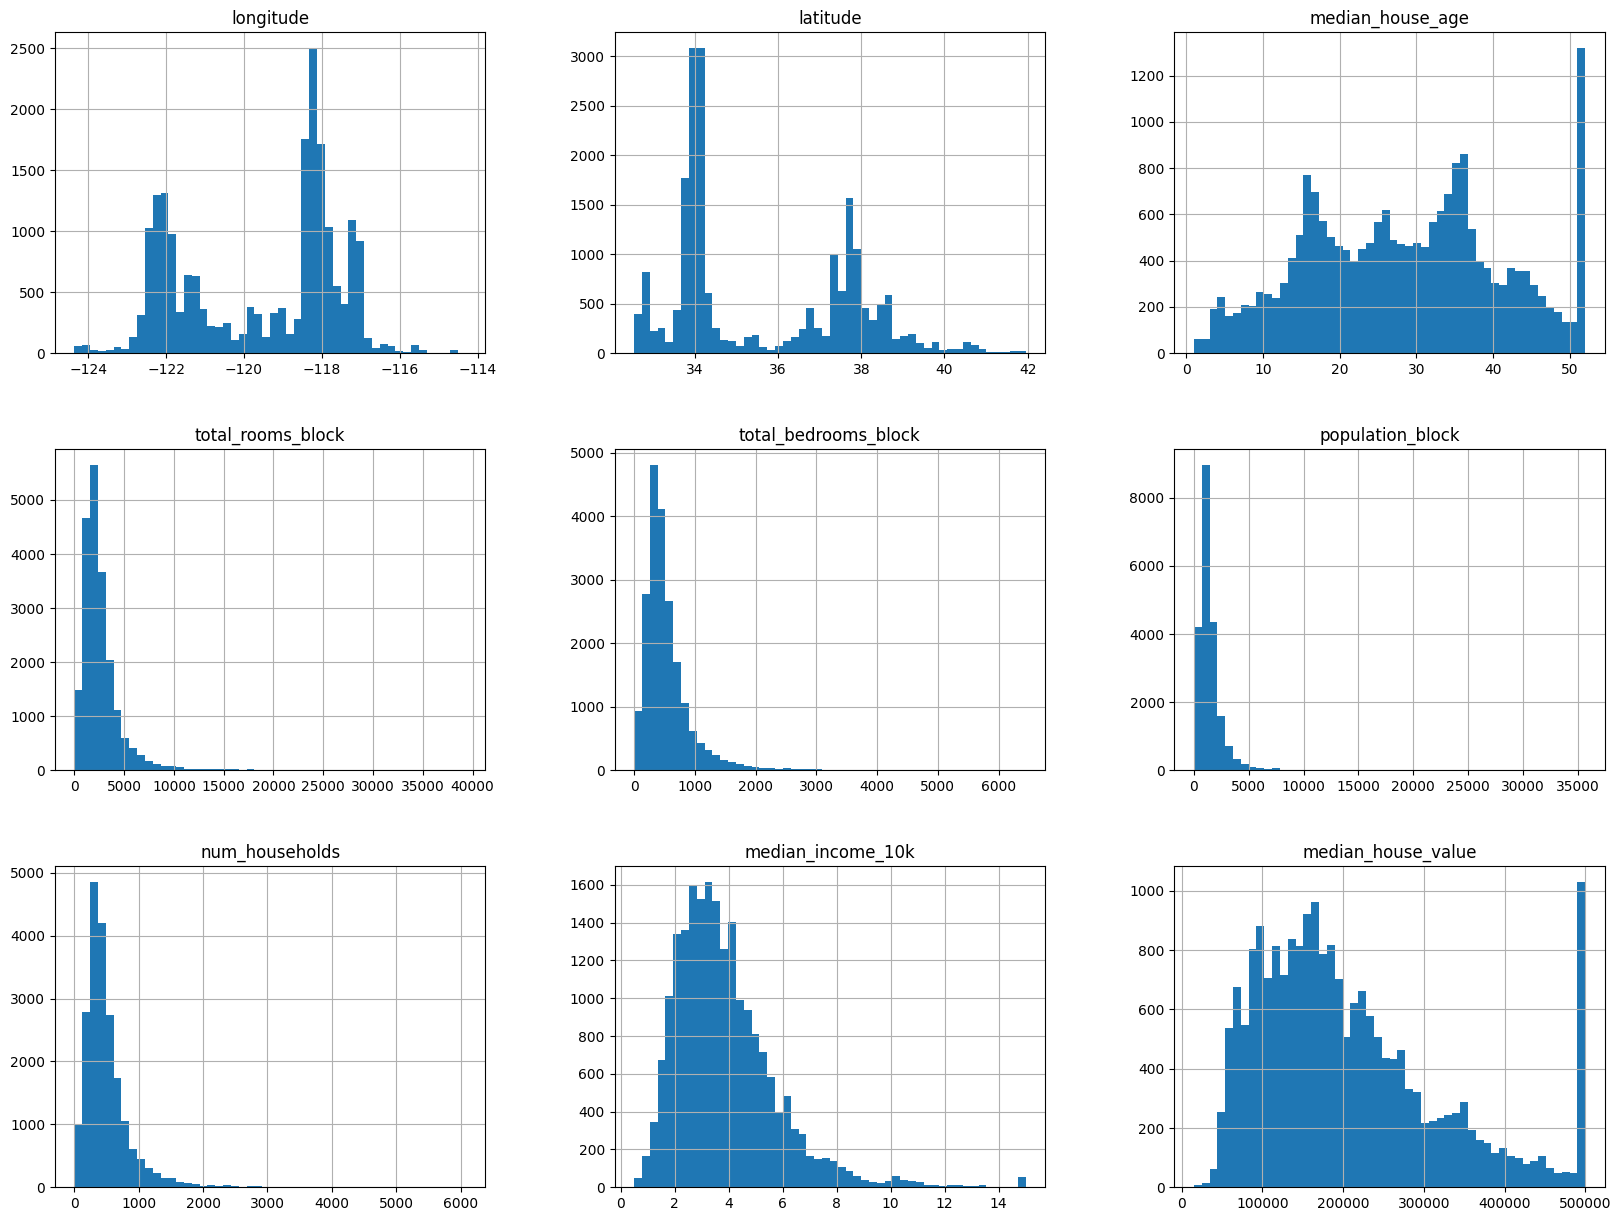

In [21]:
df.hist(bins=50, figsize=(20,15)) #50 bins due to df[age]
plt.show()

In [22]:
#remove all values above 500000 in median_house_value column because they are capped values
df=df[df["median_house_value"]<500000]
df.size

196480

In [23]:
#train test stratified split based on median_income_10k column using quantiles cuts
from sklearn.model_selection import train_test_split

# create quantile bins
df["income_cat"] = df["income_cat"] = pd.cut(df["median_income_10k"], bins=[0,1.5,3,4.5,6,np.inf], labels=[1, 2, 3, 4, 5])
# stratified split
train_data, test_data = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["income_cat"]
)

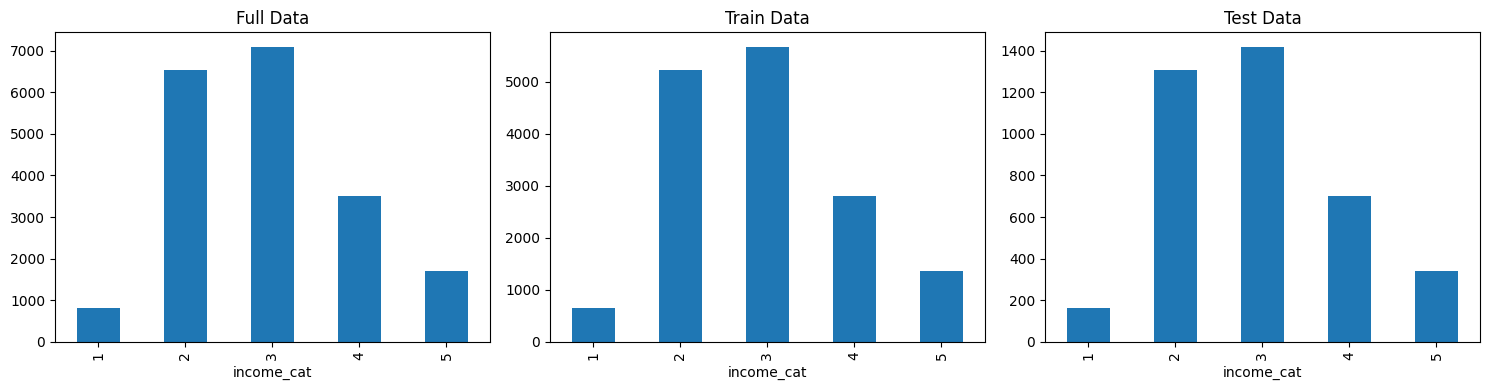

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['income_cat'].value_counts().sort_index().plot.bar(ax=axes[0])
axes[0].set_title("Full Data")

train_data['income_cat'].value_counts().sort_index().plot.bar(ax=axes[1])
axes[1].set_title("Train Data")

test_data['income_cat'].value_counts().sort_index().plot.bar(ax=axes[2])
axes[2].set_title("Test Data")

plt.tight_layout()
plt.show()

In [25]:
# drop helper column
for dataset in (train_data, test_data):
    dataset.drop("income_cat", axis=1, inplace=True)

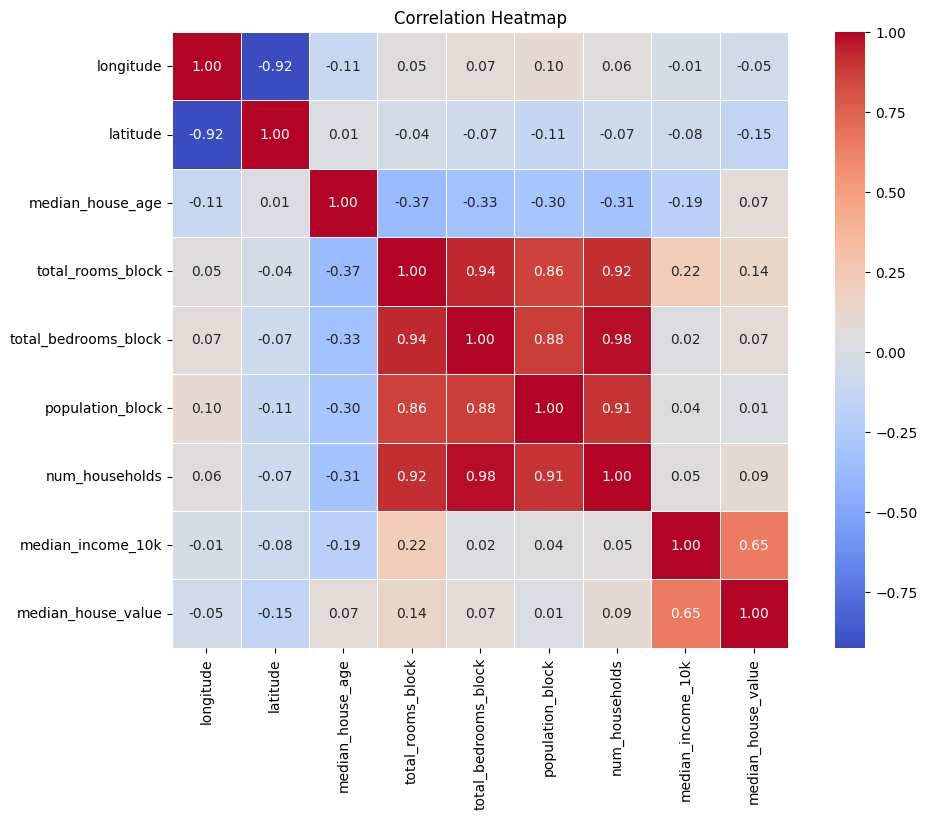

In [26]:
# Plot heatmap
corr_matrix = train_data.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [27]:
#sort correlation matrix by highest to lowest correlation by absolute value
corr_matrix_sorted = corr_matrix["median_house_value"].abs().sort_values(ascending=False)
print(corr_matrix_sorted)

median_house_value      1.000000
median_income_10k       0.649208
latitude                0.148557
total_rooms_block       0.142174
num_households          0.092148
total_bedrooms_block    0.072071
median_house_age        0.068357
longitude               0.046475
population_block        0.010607
Name: median_house_value, dtype: float64


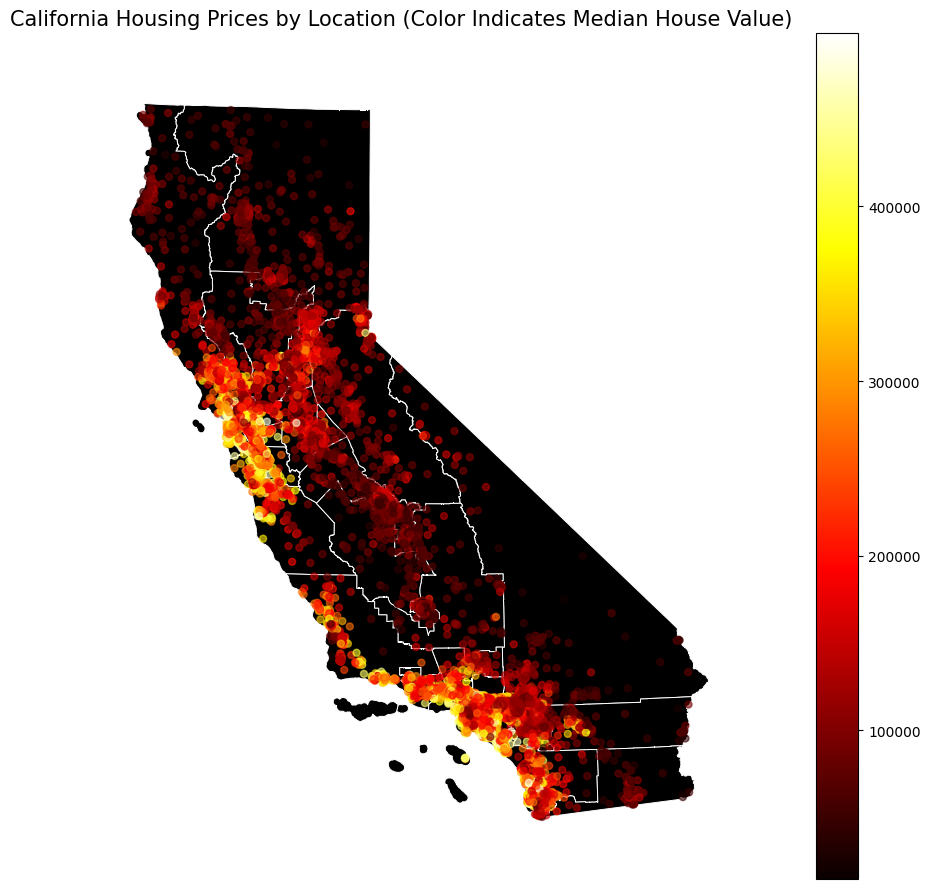

In [28]:
cali = gpd.read_file(gplt.datasets.get_path('california_congressional_districts'))

# Load your training data and convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    train_data,
    geometry=gpd.points_from_xy(train_data.longitude, train_data.latitude),
    crs="EPSG:4326"
)

proj = gcrs.AlbersEqualArea(central_latitude=37.16611, central_longitude=-119.44944)

# Plot
fig, ax = plt.subplots(figsize=(12, 9), subplot_kw={'projection': proj})
gplt.polyplot(cali, projection=proj, ax=ax, facecolor='black', edgecolor='white', linewidth=0.7)


gplt.pointplot(
    gdf,
    ax=ax,
    projection=proj,
    hue='median_house_value',
    cmap='hot',
    legend=True,
    alpha=0.6
)

# Title and layout
ax.set_title("California Housing Prices by Location (Color Indicates Median House Value)", fontsize=15)
plt.tight_layout()

#preprocessing

In [29]:

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    """
    Transforms data into similarities to cluster centers using the RBF kernel.
    """

    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(n_clusters=self.n_clusters, n_init=10, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, input_features=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]


In [30]:
# Feature engineering functions
def compute_ratio(X):
    """
    Computes the ratio of the first column to the second column.
    """
    return X[:, [0]] / X[:, [1]]


def ratio_feature_names(transformer, feature_names_in):
    return ["ratio"]



In [31]:
# Pipelines for different feature types
def make_ratio_pipeline():
    """
    Pipeline for computing ratios between two features with imputation and scaling.
    """
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(compute_ratio, feature_names_out=ratio_feature_names),
        StandardScaler()
    )


def make_log_pipeline():
    """
    Pipeline for log-transforming features with imputation and scaling.
    """
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(np.log1p, feature_names_out="one-to-one"),  # log1p for better stability
        StandardScaler()
    )


def make_categorical_pipeline():
    """
    Pipeline for categorical features: imputation and one-hot encoding.
    """
    return make_pipeline(
        SimpleImputer(strategy="most_frequent"),
        OneHotEncoder(handle_unknown="ignore")
    )


def make_default_numeric_pipeline():
    """
    Default numeric preprocessing pipeline with imputation and scaling.
    """
    return make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler()
    )

In [32]:
cluster_similarity_transformer = ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=42)

In [33]:
df.columns

Index(['longitude', 'latitude', 'median_house_age', 'total_rooms_block',
       'total_bedrooms_block', 'population_block', 'num_households',
       'median_income_10k', 'median_house_value', 'ocean_proximity',
       'income_cat'],
      dtype='object')

In [34]:
# Index(['longitude', 'latitude', 'median_house_age', 'total_rooms_block',
#        'total_bedrooms_block', 'population_block', 'num_households',
#        'median_income_10k', 'median_house_value', 'ocean_proximity',
#        'income_cat'],
#       dtype='object')

# Full preprocessing pipeline
full_preprocessing_pipeline = ColumnTransformer(
    transformers=[
        ("bedrooms_ratio", make_ratio_pipeline(), ["total_bedrooms_block", "total_rooms_block"]),
        ("rooms_per_house", make_ratio_pipeline(), ["total_rooms_block", "num_households"]),
        ("people_per_house", make_ratio_pipeline(), ["population_block", "num_households"]),
        ("log_features", make_log_pipeline(), ["total_bedrooms_block", "total_rooms_block", "population_block", "num_households","median_income_10k"]),
        ("geo_similarity", cluster_similarity_transformer, ["latitude", "longitude"]),
        ("categorical", make_categorical_pipeline(), ["ocean_proximity"])
    ],
    remainder=make_default_numeric_pipeline()
)

In [35]:
#Features and target separation

train_features = train_data.drop("median_house_value", axis=1)
train_target = train_data["median_house_value"].copy()
test_features = test_data.drop("median_house_value", axis=1)
test_target = test_data["median_house_value"].copy()


In [36]:

# Compare many regression models using TRAIN data only

def compare_regression_models(preprocessor, models, X_train, y_train, cv=10):
    """
    Compare multiple regression models using cross-validation on training data only.

    Parameters
    ----------
    preprocessor : transformer/pipeline
        Your preprocessing pipeline.
    models : dict
        Dictionary like:
        {
            "Linear Regression": LinearRegression(),
            "Random Forest": RandomForestRegressor(...)
        }
    X_train : pd.DataFrame
    y_train : pd.Series or np.array
    cv : int
        Number of CV folds.

    Returns
    -------
    results_df : pd.DataFrame
        Sorted comparison table.
    best_model_name : str
        Name of model with lowest mean CV RMSE.
    best_model : estimator
        Best estimator object (not yet fitted).
    """ 
    results = []

    for model_name, model in models.items():
        pipeline = make_pipeline(preprocessor, model)

        cv_scores = cross_val_score(
            pipeline,
            X_train,
            y_train,
            scoring="neg_mean_squared_error",
            cv=cv,
            n_jobs=-1
        )

        cv_rmse = np.sqrt(-cv_scores)

        results.append({
            "model": model_name,
            "cv_rmse_mean": cv_rmse.mean(),
            "cv_rmse_std": cv_rmse.std(),
            "cv_rmse_scores": cv_rmse
        })

        print(f"{model_name}")
        print("CV RMSE scores:", np.round(cv_rmse, 4))
        print("Mean CV RMSE:", round(cv_rmse.mean(), 4))
        print("Std CV RMSE:", round(cv_rmse.std(), 4))
        print("-" * 50)

    results_df = pd.DataFrame(results).sort_values("cv_rmse_mean", ascending=True).reset_index(drop=True)

    best_model_name = results_df.loc[0, "model"]
    best_model = models[best_model_name]

    print("\nModel comparison summary:")
    print(results_df[["model", "cv_rmse_mean", "cv_rmse_std"]])

    print(f"\nBest model based on CV RMSE: {best_model_name}")

    return results_df, best_model_name, best_model



# Final evaluation on test set AFTER model selection

def final_evaluate_regression_model(
    preprocessor,
    model,
    model_name,
    X_train,
    y_train,
    X_test,
    y_test,
    plot_top_n=15,
    n_repeats=10,
    random_state=42
):
    """
    Fit the chosen model on full training data, evaluate on test data,
    and compute permutation importance on test data.
    """

    pipeline = make_pipeline(preprocessor, model)

    # Fit on full training data
    pipeline.fit(X_train, y_train)

    # Predict on test set
    test_predictions = pipeline.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

    print(f"\nFinal chosen model: {model_name}")
    print(f"Final Test RMSE: {test_rmse:.4f}")

    # Permutation importance on original columns
    perm_result = permutation_importance(
        pipeline,
        X_test,
        y_test,
        scoring="neg_mean_squared_error",
        n_repeats=n_repeats,
        random_state=random_state
    )

    feature_names = X_test.columns.tolist()

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance_mean": perm_result.importances_mean,
        "importance_std": perm_result.importances_std
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

    print("\nPermutation Feature Importance:")
    print(importance_df)

    # Plot top features
    top_features = importance_df.head(plot_top_n).sort_values("importance_mean")

    plt.figure(figsize=(10, 6))
    plt.barh(top_features["feature"], top_features["importance_mean"])
    plt.xlabel("Permutation Importance")
    plt.ylabel("Feature")
    plt.title(f"Top {plot_top_n} Feature Importances - {model_name}")
    plt.tight_layout()
    plt.show()

    return {
        "model_name": model_name,
        "pipeline": pipeline,
        "test_rmse": test_rmse,
        "test_predictions": test_predictions,
        "feature_importance": importance_df
    }

In [37]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [38]:
#compare models using training data only
comparison_df, best_model_name, best_model = compare_regression_models(
    preprocessor=full_preprocessing_pipeline,
    models=models,
    X_train=train_features,
    y_train=train_target,
    cv=10
)

Linear Regression
CV RMSE scores: [65047.4577 60964.4194 60498.5102 62363.5349 54972.5603 60265.4504
 58662.0556 58921.3304 58502.7511 58541.8021]
Mean CV RMSE: 59873.9872
Std CV RMSE: 2544.6077
--------------------------------------------------
Ridge Regression
CV RMSE scores: [64793.5126 60938.6658 60499.7086 62358.0803 55005.9814 60257.7688
 58669.9649 58920.2817 58524.3177 58540.0118]
Mean CV RMSE: 59850.8294
Std CV RMSE: 2483.893
--------------------------------------------------
Decision Tree
CV RMSE scores: [60625.5357 60685.7593 59881.3225 60572.7425 59851.744  62200.8741
 58148.1162 59422.3831 58688.4801 59766.8636]
Mean CV RMSE: 59984.3821
Std CV RMSE: 1077.2473
--------------------------------------------------
Random Forest
CV RMSE scores: [42055.8032 43812.9306 42768.7968 46128.3134 40974.8513 43956.5261
 41721.8883 40720.2686 43370.3971 43365.815 ]
Mean CV RMSE: 42887.5591
Std CV RMSE: 1529.1718
--------------------------------------------------
Gradient Boosting
CV RMSE 


Final chosen model: Random Forest
Final Test RMSE: 40544.8739

Permutation Feature Importance:
                feature  importance_mean  importance_std
0     median_income_10k     4.853939e+09    1.063517e+08
1       ocean_proximity     2.127518e+09    7.241240e+07
2             longitude     2.110921e+09    5.463597e+07
3      population_block     2.001517e+09    8.448384e+07
4              latitude     1.791617e+09    4.408577e+07
5        num_households     1.632590e+09    2.674990e+07
6     total_rooms_block     9.865444e+08    2.816546e+07
7      median_house_age     3.596389e+08    3.010033e+07
8  total_bedrooms_block     3.350409e+08    1.259837e+07


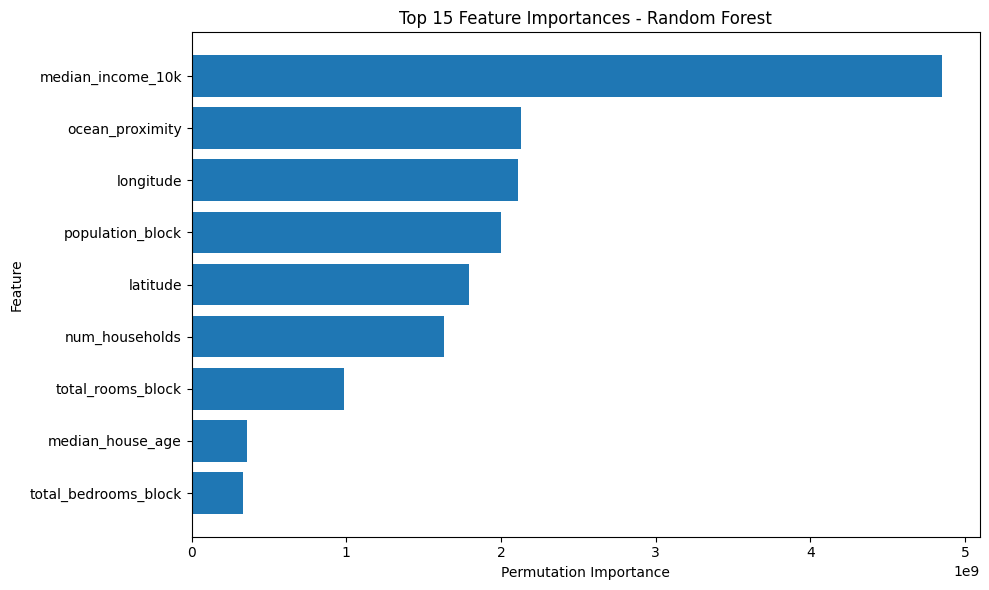

In [39]:
# final evaluation of best model on test set
final_results = final_evaluate_regression_model(
    preprocessor=full_preprocessing_pipeline,
    model=best_model,
    model_name=best_model_name,
    X_train=train_features,
    y_train=train_target,
    X_test=test_features,
    y_test=test_target,
    plot_top_n=15
)